In [1]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
from scipy import signal

## Opgave 1
Lad blokdiagrammet for et LTI system være givet ved

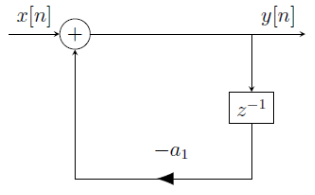

### 1. Angiv differensligningen og systemfunktionen for LTI systemet.

Systemet er et 1. ordens IIR filter og har differensligningen
$$
y[n] = x[n] - a_1 y[n-1]
$$

### 2. Redegør for om systemet er stabilt for alle valg af $a_1$

Systemfunktionen for systemet ville være

\begin{align*}
Y(z) &= X(z) - a_{1} z^{-1} Y(z)\\
H = \frac{Y(z)}{X(z)} &= \frac{1}{1 + a_1 z^{-1}}
\end{align*}

Det kan her ses at $a_1$ bestemmer systemets pol, hvilket betyder at systemet ikke er stabilt for alle valg af $a_1$, men kun for
$$
|a_1| < 1
$$

### 3. Redegør for forskellige og ligheder i magnitude- og faseresponset for LTI systemet for $a_1 = 0.9$ henholdssvis $a_1 = -0.9$

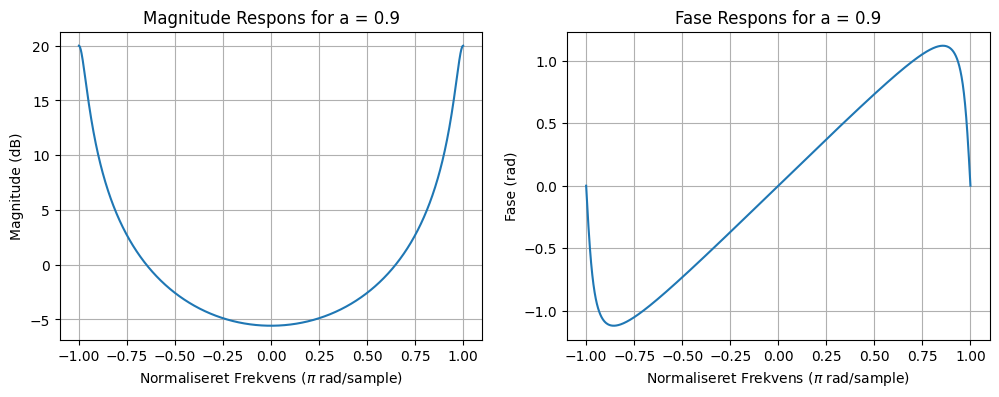

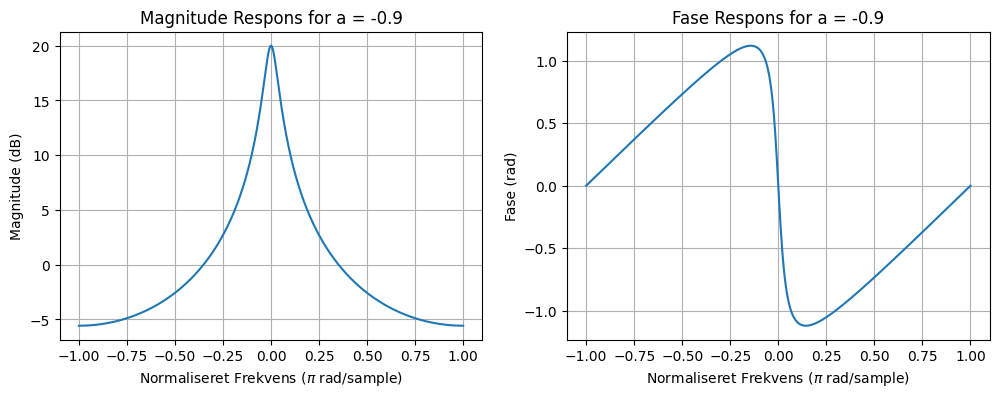

In [6]:
a = 0.9
num = [1]
den = [1, a]

w = np.linspace(-np.pi, np.pi, 1000)
_, H = signal.freqz(num, den, worN=w)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(w / np.pi, 20 * np.log10(np.abs(H)))
plt.title('Magnitude Respons for a = 0.9')
plt.xlabel('Normaliseret Frekvens ($\pi$ rad/sample)')
plt.ylabel('Magnitude (dB)')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(w / np.pi, np.angle(H))
plt.title('Fase Respons for a = 0.9')
plt.xlabel('Normaliseret Frekvens ($\pi$ rad/sample)')
plt.ylabel('Fase (rad)')
plt.grid(True)

a = -0.9
den = [1, a]

_, H = signal.freqz(num, den, worN=w)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(w / np.pi, 20 * np.log10(np.abs(H)))
plt.title('Magnitude Respons for a = -0.9')
plt.xlabel('Normaliseret Frekvens ($\pi$ rad/sample)')
plt.ylabel('Magnitude (dB)')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(w / np.pi, np.angle(H))
plt.title('Fase Respons for a = -0.9')
plt.xlabel('Normaliseret Frekvens ($\pi$ rad/sample)')
plt.ylabel('Fase (rad)')
plt.grid(True)

plt.show()

Det kan ses i plottene, at det er præcis samme magnitude- og faserespons, men at forskudt med en frekvens på $\pi$ radianer.

## Opgave 2
Diskret-tids signalbehandling finder anvendelse ganske mange stedet. Et eksempel på dette er et Savitzsky-Golay filter (her citeret fra Wikipedia): "A Savitzky-Golay filter is a digital filter that can be applied to a set of digital data point for the purpose of smoothing the data, that is, to increase the precision of the data without distorting the signal tendency." Savitzky-Golay filteret findes i mange varianter. Her i kigger vi på varianten givet ved differensligningen:
$$
y[n] = \frac{1}{35} (- 3x[n + 2] + 12x[n + 1] + 17x[n] + 12x[n - 1] - 3x[n - 2])
$$

Hvor $x[n]$ og $y[n]$ som sædvanlig betegner input til og output fra filteret.

### 1. Analyser filteret og redegør for dets egenskaber.

Filteret er ikke defineret af en differensligning, så outputtet kun afhænger af inputtet. Den virker som en slags gennemsnits filter, hvilket giver mening ift. at wikipedia citatet siger, at den er til at gøre data mere "smooth". Det kan ses ved at den forstærker signalet ved $n$, tage noget af signalet med fra $n \pm 1$ og trækker signalet fra ved $n \pm 2$. 

Da den bruger fremtidige værdier betyder det også, at den ikke er kausal.

Den er dog lineær da 

\begin{align*}
Y(z) &= \frac{1}{35} (-3z^{2}X(z) + 12z^{1}X(z) + 17X(z) + 12z^{-1}X(z) - 3z^{-2}X(z))\\
H(z) = \frac{Y(z)}{X(z)} &= \frac{-3z^{2} + 12z^{1} + 17 + 12z^{-1} - 3z^{-2}}{35}
\end{align*}

### 2. Lad et støjfyldt signal $x[n]$ med 16 samples være givet ved
$$
x[n] = \{ \underset{\uparrow}{-174}, -43, -106, -46, -188, -49, -99, -168, 89, -169, 154, -135, 171, -3, 98, 89 \}
$$

som sædvanligt angiver pilen $n=0$. Det antages at $x[n] = 0$ for alle andre værdier af $n$ end de her angivne. Filtrer det støjfyldte signal gennem Savitzky-Golay filteret og plot input og output på samme graf. Kommenter på resultatet.

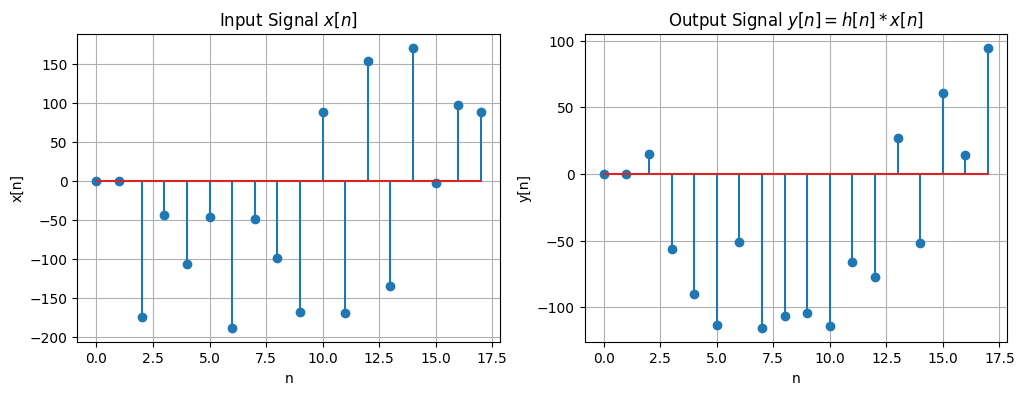

In [26]:
x = np.array([0, 0, -174, -43, -106, -46, -188, -49, -99, -168, 89, -169, 154, -135, 171, -3, 98, 89])
h = np.array([-3, 12, 17, 12, -3])/35
y = signal.lfilter(h, 1, x)
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.stem(x)
plt.title('Input Signal $x[n]$')
plt.xlabel('n')
plt.ylabel('x[n]')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.stem(y)
plt.title('Output Signal $y[n] = h[n] * x[n]$')
plt.xlabel('n')
plt.ylabel('y[n]')
plt.grid(True)

plt.show()

Det kan ses i output signalet at der er en generel sinus bølge lignende form i dataen, hvilket ikke kan ses lige så tydeligt i inputtet.

## Opgave 3
Antag at der ved hjælp af vinduesmetoden skal designes et type-I lavpas filter med specifikationer
$$
\omega_p = 0.1\pi, \omega_s = 0.2\pi, A_p = 0.2 dB, A_s = 50 dB,
$$

og at der skal bruges et Blackman vindue.

### 1. Beregn værdien af $M$, lav filteret og plots dets impulsrespons samt magnitude- og faserespons.

$M$ kan estimeres ud fra tabel 10.3
$$
\Delta\omega = \omega_s - \omega_p = 0.1
$$
$$
0.1\pi = \frac{11\pi}{L} \Leftrightarrow L = 110
$$
$$
M = 111
$$



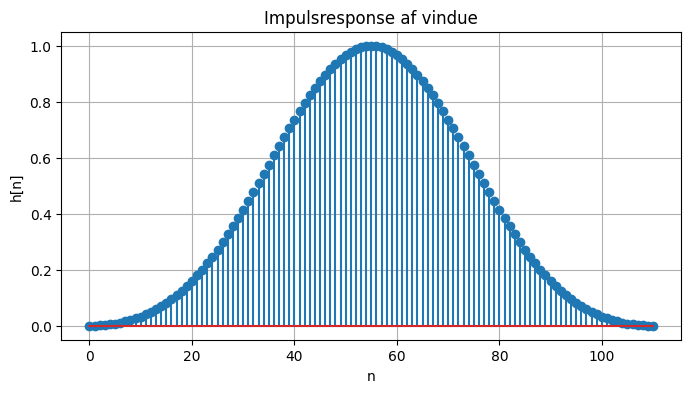

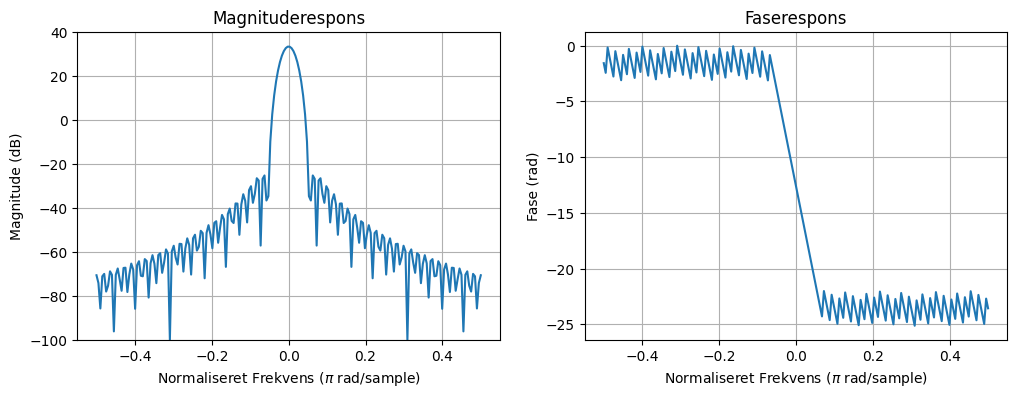

In [61]:
M = 111
h = np.blackman(M)
plt.figure(figsize=(8, 4))
plt.stem(np.arange(M), h)
plt.title('Impulsresponse af vindue')
plt.xlabel('n')
plt.ylabel('h[n]')
plt.grid(True)
plt.show()

w = np.linspace(-0.5*np.pi, 0.5*np.pi, 200)
_, H = signal.freqz(h, worN=w)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(w / np.pi, 20 * np.log10(np.abs(H)))
plt.title('Magnituderespons')
plt.xlabel('Normaliseret Frekvens ($\pi$ rad/sample)')
plt.ylabel('Magnitude (dB)')
plt.ylim(-100, 40)
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(w / np.pi, np.unwrap(np.angle(H)))
plt.title('Faserespons')
plt.xlabel('Normaliseret Frekvens ($\pi$ rad/sample)')
plt.ylabel('Fase (rad)')
plt.grid(True)

plt.show()

### 2. Antag dernæst at der i den givne signalbehandlingsapplikation ikke er de nødvendige ressourcer til at køre et FIR filter med længden $M$. I stedet er det kun muligt at bruge et filter på en længde af cirka $M/2$. Diskuter hvilke effekter det får for filterets egenskaber.

Dette vil gøre at der er lavere frekvensopløsning og at der bliver en mindre skarp overgang fra pass- til stopbånd. Det betyder også at amplituden af vinduets ripples kan blive større. Dette kan ses, hvis det plottes.

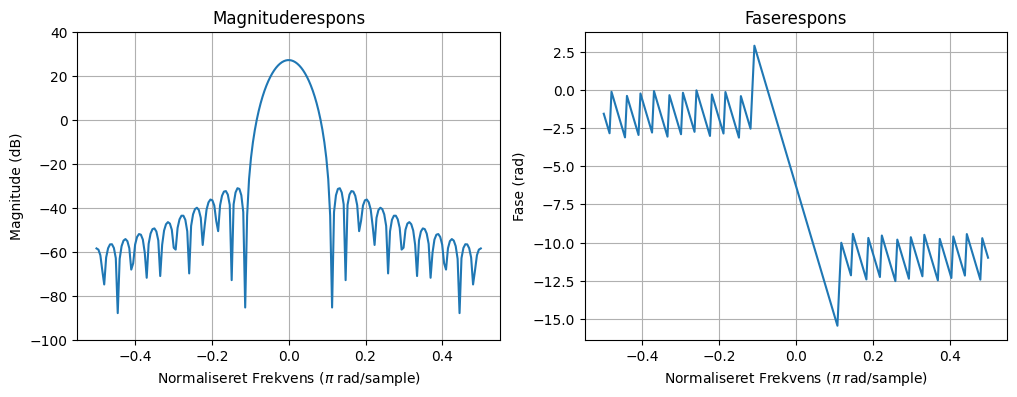

In [62]:
M = 110/2
h = np.blackman(M)

w = np.linspace(-0.5*np.pi, 0.5*np.pi, 200)
_, H = signal.freqz(h, worN=w)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(w / np.pi, 20 * np.log10(np.abs(H)))
plt.title('Magnituderespons')
plt.xlabel('Normaliseret Frekvens ($\pi$ rad/sample)')
plt.ylabel('Magnitude (dB)')
plt.ylim(-100, 40)
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(w / np.pi, np.unwrap(np.angle(H)))
plt.title('Faserespons')
plt.xlabel('Normaliseret Frekvens ($\pi$ rad/sample)')
plt.ylabel('Fase (rad)')
plt.grid(True)

plt.show()

## Opgave 4
Et Lineær Tidsinvariant (LTI) digitalt system 𝑆 har input signal 𝑥[𝑛], output signal 𝑦[𝑛]. Systemet er kausalt og givet ved differensligningen:
$$
S: y[n] = \alpha \cdot y[n - 1] + x[n],
$$
hvor $\alpha$ er et reelt tal.

Lad os antage at:
$$
y[n] = 0, \text{ når } n < 0,
$$

og signalet $x[n]$ være givet ved:
$$
x[n] =
\begin{cases}
1 & når \; n \geq 0 \\
0 & ellers
\end{cases}
$$

### 1. Beregn output $y[0]$, $y[1]$ og $y[2]$, fra systemet, når input signalet er $x[n]$ ovenfor. 

Beregning af $y[0]$

\begin{align*}
y[0] &= \alpha y[-1] + x[0]\\
&= \alpha \cdot 0 + 1\\
&= 1
\end{align*}

Beregning af $y[1]$

\begin{align*}
y[1] &= \alpha y[0] + x[1]\\
&= \alpha \cdot 1 + 1\\
&= \alpha + 1
\end{align*}

Beregning af $y[2]$

\begin{align*}
y[2] &= \alpha y[1] + x[2]\\
&= \alpha \cdot (\alpha + 1) + 1\\
&= \alpha^2 + \alpha + 1
\end{align*}

### 2. Beregn $Z$-transformationen $H(z)$ for overføringsfunktionen for $S$ inklusiv ROC.

\begin{align*}
Y(z) &= \alpha z^{-1} Y(z) + X(z)\\
Y(z) - \alpha z^{-1} Y(z) &= X(z)\\
H(z) = \frac{Y(z)}{X(z)} &= \frac{1}{1 - \alpha z^{-1}}
\end{align*}

Den har en pol i $z=\alpha$ pga. leddet $\alpha z^{-1}$. Da systemet er et kausalt system vil funktionen konvergere i
$$
ROC: |z| > \alpha
$$

### 3. For hvilke værdier af $\alpha$ er systemet stabilt? (argumenter for dit svar).

Systemet vil være stabilt så længe polen ligger indenfor enhedscirklen. Dette vil gælde så længe
$$
|\alpha| < 1
$$

### 4. Lad nu $\alpha = \frac{1}{2}$. Skitser grafen for $|H(e^{ j\omega })|$. Er $|H(e^{ j\omega })|$ periodisk?

Den skulle meget gerne være periodisk med en periode på $2 \pi$, da $|H( e^{ j\omega } )| = |H( e^{ j(\omega + 2\pi) } )|$

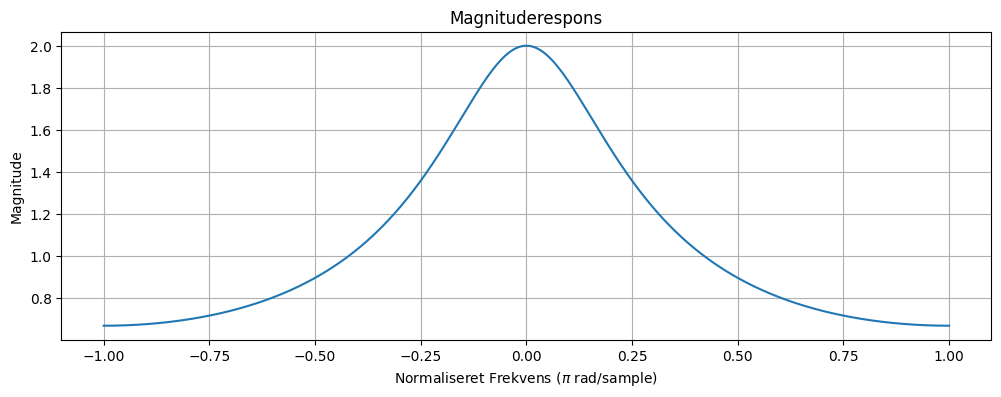

In [64]:
num = [1]
den = [1, -1/2]

w = np.linspace(-np.pi, np.pi, 1000)
_, H = signal.freqz(num, den, worN=w)

plt.figure(figsize=(12, 4))

plt.plot(w / np.pi, np.abs(H))
plt.title('Magnituderespons')
plt.xlabel('Normaliseret Frekvens ($\pi$ rad/sample)')
plt.ylabel('Magnitude')
plt.grid(True)
plt.show()

### 5. Lad nu $\beta$ være et reelt tal og $T$ et Lineær Tidsinvariant (LTI) og kausalt digitalt system med $Z$-transformationen givet ved:
$$
G(z) = 1 + \beta \cdot z^{-1}, ROC \; |z| > |\beta|
$$

Findes der et tal $\beta$ således at kaskade koblingen af $T$ og $S$, er et system som har endeligt impuls svar? (argumenter for dit svar)

Kaskade koblingen mellem $T$ og $S$ vil være produktet af deres systemfunktioner
$$
H(z) \cdot G(z) = \frac{1}{1 - \alpha z^{-1}} \cdot (1 + \beta \cdot z^{-1})
$$

For at gøre det til et FIR system skal polerne fjernes, hvilket fjerner feedbacken i systemet. Det kan ses at $G(z)$ vil gå ud med nævneren, hvis $\beta = \alpha$, hvilket også ville fjerne polen i systemet og gøre kaskade koblingen til $H(z) \cdot G(z) = 1$, hvilket har et endeligt impuls svar. Der findes da et reelt tal, som gør det muligt, hvilket er
$$
\beta = \alpha
$$

## Opgave 5
Lad $N$ er et helt positivt tal og lad $W_N$ være $N \times N$ DFT-matricen (Diskrete-Fourier-Transformationmatricen).

### 1. Beregn matricen $W_N$ for $N = 2$ og beregn herefter DFT-transformationen af signalet $x[n]$, for $n=0$ og 1, ved hjælp af $W_N$:
$$
x[n] = \begin{cases}
1 & n=0 \\
2 & n=1 \\
0 & ellers
\end{cases}
$$

(det er ikke tilstrækkeligt blot at vise resultaterne, vis dine udregninger).

DFT-matricen sættes op som vist i efter ligning 7.33
$$
W_{N} = 
\begin{bmatrix}
1 & 1 & \\
1 & W_{4}^{1}
\end{bmatrix}
=
\begin{bmatrix}
1 & 1 \\
1 & e^{ -j \frac{2\pi}{2} 1 }
\end{bmatrix}
=
\begin{bmatrix}
1 & 1 \\
1 & -1
\end{bmatrix}
$$

Derefter kan signalet sættes op en Matrix
$$
x_{N} =
\begin{bmatrix}
1 \\
2
\end{bmatrix}
$$

Dette kan ganges på DFT-matricen for at få DFT-transformationen
$$
X_{N} = 
\begin{bmatrix}
1 & 1 \\
1 & -1
\end{bmatrix}
\begin{bmatrix}
1 \\
2
\end{bmatrix}
=
\begin{bmatrix}
1 \cdot 1 + 1 \cdot 2 \\
1 \cdot 1 + (-1) \cdot 2
\end{bmatrix}
=
\begin{bmatrix}
3 \\
-1
\end{bmatrix}
$$

### 2. Et kontinuert signal er båndbegrænset til 1000Hz. Signalet samples med 14 kHz (der er ingen aliasering ved anvendelse af denne samplingsfrekvens) og der opsamles $N=1024$ samples. Bestem den fysiske frekvens der korresponderer til $k=197$, når DFT-koefficienterne for de 1024 samples beregnes.

Frekvensen kan blive fundet med ligning 7.197
$$
F_k = \frac{k}{NT} = \frac{197}{1024 \cdot \frac{1}{14000}} = 2693.36 Hz
$$

### 3. Der laves en en spektralanalyse af det kontinuert signal ved hjælp af DFT. Det viser det sig at DFT-koefficienterne der korresponderer til de fysiske frekvenser som er større end 1000Hz ikke alle er 0. Forklar hvorfor disse DFT-koefficienterne ikke behøver at være præcist 0.

Dette sker da der under sampling højst sandsynligt har været brugt et vindue med relativt store ripples. Dette kan give spectral leakage, hvilket gør at støj fra over 1000 Hz kan komme igennem på trods af båndbegrænsningen.